In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv(r"C:\Users\abhin\Downloads\US_Customer_Insights_Dataset.csv")

display(df.head())
df.info()
print(df.isnull().sum())

,CustomerID,Name,State,Education,Gender,Age,Married,NumPets,JoinDate,TransactionDate,MonthlySpend,DaysSinceLastInteraction
0,CUST10319,Scott Perez,Florida,High School,Non-Binary,47,Yes,1,9/19/21,9/2/24,1281.74,332
1,CUST10695,Jennifer Burton,Washington,Master,Male,72,Yes,0,4/5/24,6/2/24,429.46,424
2,CUST10297,Michelle Rogers,Arizona,Master,Female,40,Yes,2,7/24/24,2/28/25,510.34,153
3,CUST10103,Brooke Hendricks,Texas,Master,Male,27,Yes,0,8/12/23,3/29/25,396.47,124
4,CUST10219,Karen Johns,Texas,High School,Female,28,Yes,1,12/6/21,7/24/22,139.68,1103


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10675 entries, 0 to 10674
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                10675 non-null  object 
 1   Name                      10675 non-null  object 
 2   State                     10675 non-null  object 
 3   Education                 10675 non-null  object 
 4   Gender                    10675 non-null  object 
 5   Age                       10675 non-null  int64  
 6   Married                   10675 non-null  object 
 7   NumPets                   10675 non-null  int64  
 8   JoinDate                  10675 non-null  object 
 9   TransactionDate           10675 non-null  object 
 10  MonthlySpend              10675 non-null  float64
 11  DaysSinceLastInteraction  10675 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 1000.9+ KB
CustomerID                  0
Name                      

In [4]:
num_cols = ['Age', 'MonthlySpend', 'DaysSinceLastInteraction']
print(df[num_cols].agg(['mean', 'median', 'std']))

print("Gender Mode:", df['Gender'].mode()[0])
print("Education Mode:", df['Education'].mode()[0])
print("Married Mode:", df['Married'].mode()[0])

              Age  MonthlySpend  DaysSinceLastInteraction
mean    49.474567    331.610315                538.469883
median  49.000000    282.110000                445.000000
std     18.221365    225.799253                398.766747
Gender Mode: Male
Education Mode: Master
Married Mode: No


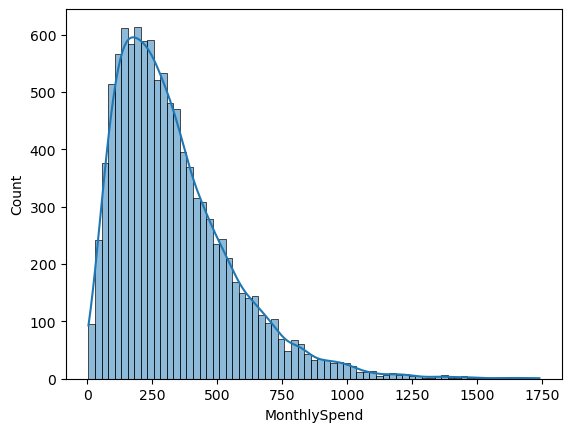

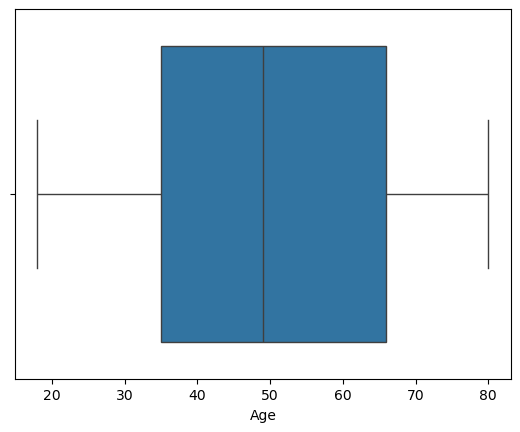

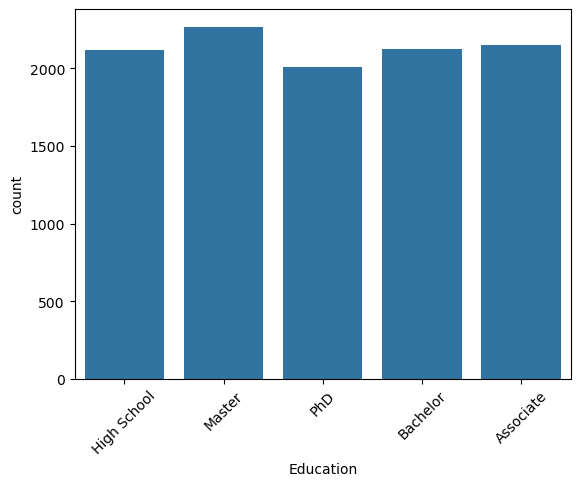

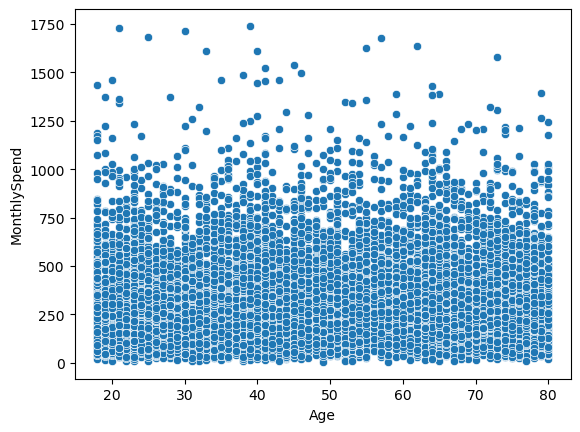

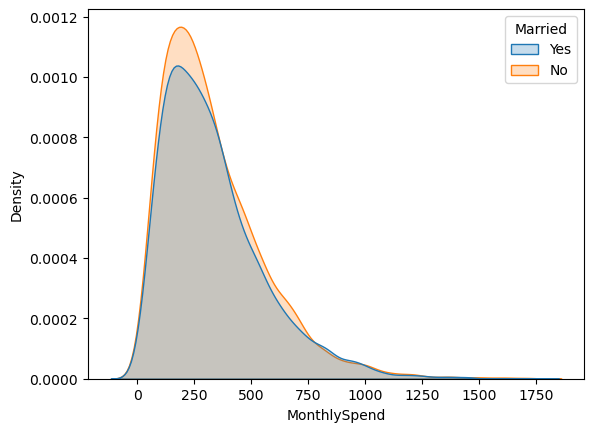

In [5]:
sns.histplot(df['MonthlySpend'], kde=True)
plt.show()

sns.boxplot(x=df['Age'])
plt.show()

sns.countplot(x='Education', data=df)
plt.xticks(rotation=45)
plt.show()

sns.scatterplot(x='Age', y='MonthlySpend', data=df)
plt.show()

sns.kdeplot(data=df, x='MonthlySpend', hue='Married', fill=True)
plt.show()

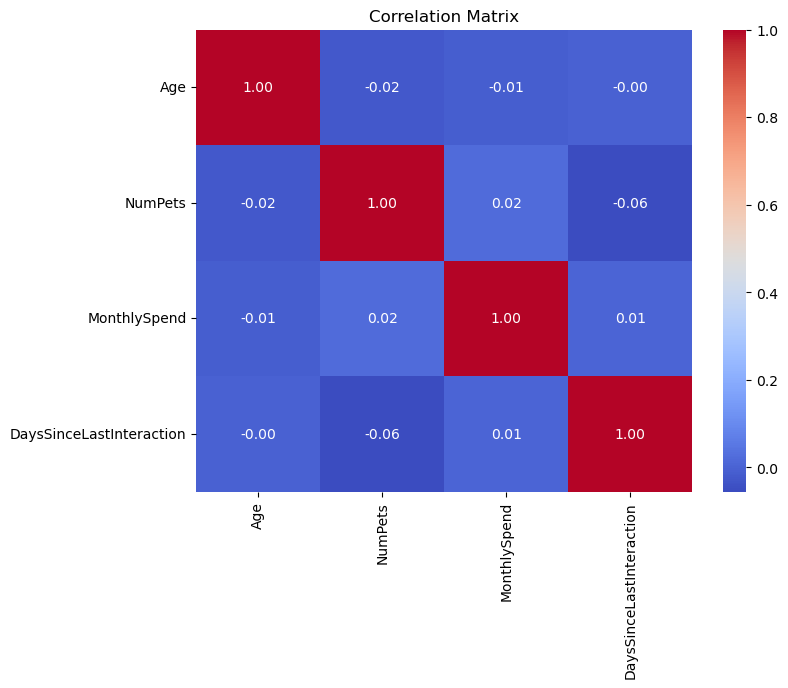

In [8]:
# Correlation Matrix (Visual Heatmap)
numeric_df = df[['Age', 'NumPets', 'MonthlySpend', 'DaysSinceLastInteraction']]

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [6]:
numeric_df = df[['Age', 'NumPets', 'MonthlySpend', 'DaysSinceLastInteraction']]
print(numeric_df.corr())

print(pd.crosstab(df['Gender'], df['Married']))

print(df.groupby('Education')['MonthlySpend'].mean())
print(df.groupby('State')['MonthlySpend'].mean().head())

                               Age   NumPets  MonthlySpend  \
Age                       1.000000 -0.023035     -0.012323   
NumPets                  -0.023035  1.000000      0.020647   
MonthlySpend             -0.012323  0.020647      1.000000   
DaysSinceLastInteraction -0.003970 -0.055227      0.006081   

                          DaysSinceLastInteraction  
Age                                      -0.003970  
NumPets                                  -0.055227  
MonthlySpend                              0.006081  
DaysSinceLastInteraction                  1.000000  
Married       No   Yes
Gender                
Female      1797  1616
Male        1892  1899
Non-Binary  1894  1577
Education
Associate      327.884408
Bachelor       331.884753
High School    332.215712
Master         334.252305
PhD            331.690090
Name: MonthlySpend, dtype: float64
State
Arizona       341.489135
California    339.183492
Colorado      323.083462
Florida       327.696892
Georgia       328.354648
Nam

In [7]:


print("--- HYPOTHESIS TESTING RESULTS ---\n")

# 1. T-TEST: Do males and females spend differently?

males = df_clean[df_clean['Gender'] == 'Male']['MonthlySpend']
females = df_clean[df_clean['Gender'] == 'Female']['MonthlySpend']


t_stat, p_val = stats.ttest_ind(males, females)
print(f"1. Gender vs Spend (T-test) | P-value: {p_val:.4f}")
if p_val < 0.05:
    print("   -> Result: Males and females spend significantly differently.\n")
else:
    print("   -> Result: No significant difference in spending between genders.\n")


# 2. ANOVA: Does education level impact average monthly spend?

edu_groups = []
for name, group_data in df_clean.groupby('Education'):
    edu_groups.append(group_data['MonthlySpend'])


f_stat, p_val = stats.f_oneway(*edu_groups)
print(f"2. Education vs Spend (ANOVA) | P-value: {p_val:.4f}")
if p_val < 0.05:
    print("   -> Result: Education level significantly impacts how much people spend.\n")
else:
    print("   -> Result: Education level does not significantly impact spending.\n")

# 3. CHI-SQUARE: Is marital status related to the number of pets owned?

chi_table = pd.crosstab(df_clean['Married'], df_clean['NumPets'])


chi2_stat, p_val, degrees_of_freedom, expected_values = stats.chi2_contingency(chi_table)
print(f"3. Married vs Pets (Chi-Square) | P-value: {p_val:.4f}")
if p_val < 0.05:
    print("   -> Result: Marital status is strongly related to owning pets.\n")
else:
    print("   -> Result: No relation between marital status and owning pets.\n")

# 4.Are older people less active :
correlation_coefficient, p_val = stats.pearsonr(df_clean['Age'], df_clean['DaysSinceLastInteraction'])

print(f"4. Age vs Inactivity (Pearson) | P-value: {p_val:.4f} | Correlation: {correlation_coefficient:.2f}")
if p_val < 0.05:
    if correlation_coefficient > 0:
        print("   -> Result: Significant relation. As age increases, inactivity increases (older people are less active).\n")
    else:
        print("   -> Result: Significant relation. As age increases, inactivity decreases (older people are more active).\n")
else:
    print("   -> Result: Age has no significant relation to how active they are.\n")

# 5. ANOVA: Does state-wise spend vary significantly?

state_groups = []
for name, group_data in df_clean.groupby('State'):
    state_groups.append(group_data['MonthlySpend'])


f_stat, p_val = stats.f_oneway(*state_groups)
print(f"5. State vs Spend (ANOVA) | P-value: {p_val:.4f}")
if p_val < 0.05:
    print("   -> Result: The state a customer lives in significantly changes how much they spend.\n")
else:
    print("   -> Result: Spending is relatively the same across all states.\n")


--- HYPOTHESIS TESTING RESULTS ---

1. Gender vs Spend (T-test) | P-value: 0.7345
   -> Result: No significant difference in spending between genders.

2. Education vs Spend (ANOVA) | P-value: 0.9224
   -> Result: Education level does not significantly impact spending.

3. Married vs Pets (Chi-Square) | P-value: 0.0000
   -> Result: Marital status is strongly related to owning pets.

4. Age vs Inactivity (Pearson) | P-value: 0.6817 | Correlation: -0.00
   -> Result: Age has no significant relation to how active they are.

5. State vs Spend (ANOVA) | P-value: 0.3457
   -> Result: Spending is relatively the same across all states.



In [8]:

males = df_clean[df_clean['Gender'] == 'Male']['MonthlySpend']
females = df_clean[df_clean['Gender'] == 'Female']['MonthlySpend']
t_stat, p_val_t = stats.ttest_ind(males, females)
print(f"1. Gender vs Spend (T-test) P-value: {p_val_t}")

edu_groups = [group['MonthlySpend'] for name, group in df_clean.groupby('Education')]
f_stat_edu, p_val_edu = stats.f_oneway(*edu_groups)
print(f"2. Education vs Spend (ANOVA) P-value: {p_val_edu}")

chi_table = pd.crosstab(df_clean['Married'], df_clean['NumPets'])
chi2, p_val_chi, dof, expected = stats.chi2_contingency(chi_table)
print(f"3. Married vs Pets (Chi-Square) P-value: {p_val_chi}")

corr, p_val_corr = stats.pearsonr(df_clean['Age'], df_clean['DaysSinceLastInteraction'])
print(f"4. Age vs Activity (Pearson) P-value: {p_val_corr}")

state_groups = [group['MonthlySpend'] for name, group in df_clean.groupby('State')]
f_stat_state, p_val_state = stats.f_oneway(*state_groups)
print(f"5. State vs Spend (ANOVA) P-value: {p_val_state}")

1. Gender vs Spend (T-test) P-value: 0.7344892727022859
2. Education vs Spend (ANOVA) P-value: 0.922359467759936
3. Married vs Pets (Chi-Square) P-value: 2.3957232932397494e-37
4. Age vs Activity (Pearson) P-value: 0.6816905437300954
5. State vs Spend (ANOVA) P-value: 0.34571886479238273


In [10]:
# BUSINESS INSIGHTS & STRATEGY
print("1. Married customers are highly likely to own pets. Create bundle deals for family and pet products.")

print("2. Arizona and Ohio have the highest spend. Focus advertising budgets on these high-value states.")

print("3. Gender does not affect monthly spend. Save money by running universal, gender-neutral marketing campaigns.")

print("4. Age does not cause inactivity. Trigger 'We Miss You' emails based on last login date, not the customer's age.")

print("5. Education level doesn't impact spending. Promote your premium and luxury products to all customers universally.")

1. Married customers are highly likely to own pets. Create bundle deals for family and pet products.
2. Arizona and Ohio have the highest spend. Focus advertising budgets on these high-value states.
3. Gender does not affect monthly spend. Save money by running universal, gender-neutral marketing campaigns.
4. Age does not cause inactivity. Trigger 'We Miss You' emails based on last login date, not the customer's age.
5. Education level doesn't impact spending. Promote your premium and luxury products to all customers universally.
